In [2]:
# SafeSight PPE - Environment Setup

!pip install -q ultralytics

import torch
import ultralytics

print("PyTorch version:", torch.__version__)
print("Ultralytics version:", ultralytics.__version__)

if torch.cuda.is_available():
    print("GPU ready:", torch.cuda.get_device_name(0))
else:
    print("GPU not detected. Using CPU.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 10.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
PyTorch version: 2.11.0+cu130
Ultralytics version: 8.4.174
GPU ready: Tesla T4


In [3]:
# SafeSight PPE - Load Baseline YOLO Model

from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("YOLO11 model loaded successfully.")
print("Model classes:")
print(model.names)

YOLO11 model loaded successfully.
Model classes:
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remot

Saving 1280x720_21_A-1440x1080.jpg to 1280x720_21_A-1440x1080 (1).jpg

image 1/1 /content/1280x720_21_A-1440x1080 (1).jpg: 480x640 2 persons, 9.1ms
Speed: 2.4ms preprocess, 9.1ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)


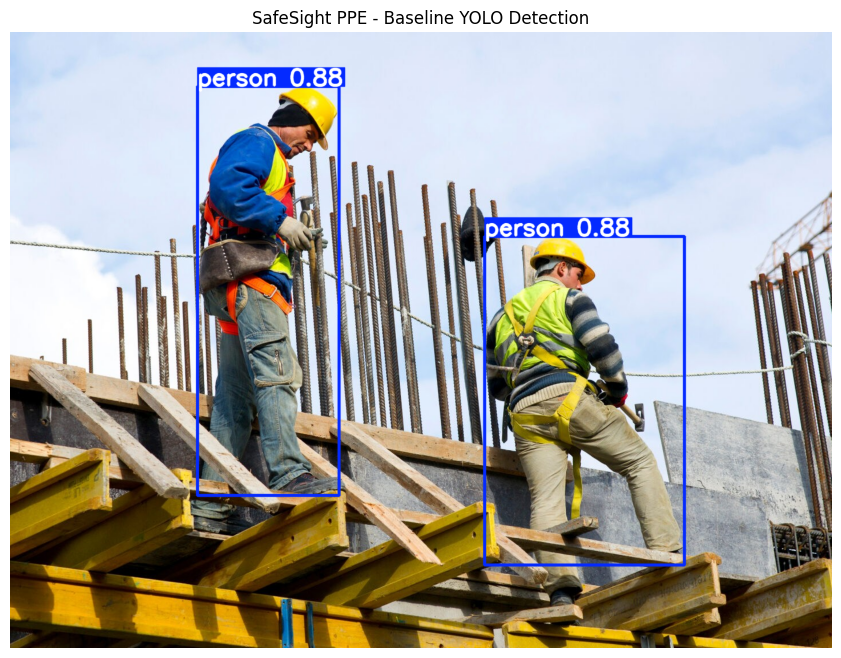

In [5]:
# SafeSight PPE - First Baseline Inference

from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

# Upload one construction-site image
uploaded = files.upload()

# Get the uploaded file name
image_path = next(iter(uploaded))

# Run YOLO inference
results = model(image_path, conf=0.25)

# Display the annotated result
annotated_image = results[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(annotated_image[..., ::-1])  # Convert BGR to RGB
plt.axis("off")
plt.title("SafeSight PPE - Baseline YOLO Detection")
plt.show()

### Understanding Check — Baseline YOLO Inference

**What does this section do?**  
This section runs a pretrained YOLO11 model on a real construction-site image. The model detected both workers and drew bounding boxes around them with confidence scores.

**Why was this done before PPE-specific training?**  
This gives me a baseline and confirms that the object-detection pipeline works before I customize the model. The pretrained model can recognize people, but it does not include PPE-specific classes such as hard hats or safety vests.

**What happens if I change the confidence threshold?**  
Lowering the confidence threshold may allow more detections to appear, including weaker or incorrect detections. Raising the threshold makes the model more selective, but it could also remove real objects that the model is less confident about.

**Observed threshold test:**  
When I increased the confidence threshold from 0.25 to 0.90, both worker detections disappeared because their confidence scores were approximately 0.88. This confirmed that setting the threshold too high can remove valid detections.

In [6]:
# SafeSight PPE - Inspect Raw Baseline Detections

result = results[0]

for box in result.boxes:
    class_id = int(box.cls[0])
    class_name = result.names[class_id]
    confidence = float(box.conf[0])
    coordinates = box.xyxy[0].tolist()

    print("Class:", class_name)
    print(f"Confidence: {confidence:.2f}")
    print("Bounding box [x1, y1, x2, y2]:", coordinates)
    print("-" * 40)

Class: person
Confidence: 0.88
Bounding box [x1, y1, x2, y2]: [831.8482666015625, 358.6383056640625, 1181.5963134765625, 934.5781860351562]
----------------------------------------
Class: person
Confidence: 0.88
Bounding box [x1, y1, x2, y2]: [328.2813720703125, 95.18341827392578, 576.7978515625, 812.5387573242188]
----------------------------------------



image 1/1 /content/1280x720_21_A-1440x1080 (1).jpg: 480x640 (no detections), 9.0ms
Speed: 2.2ms preprocess, 9.0ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)


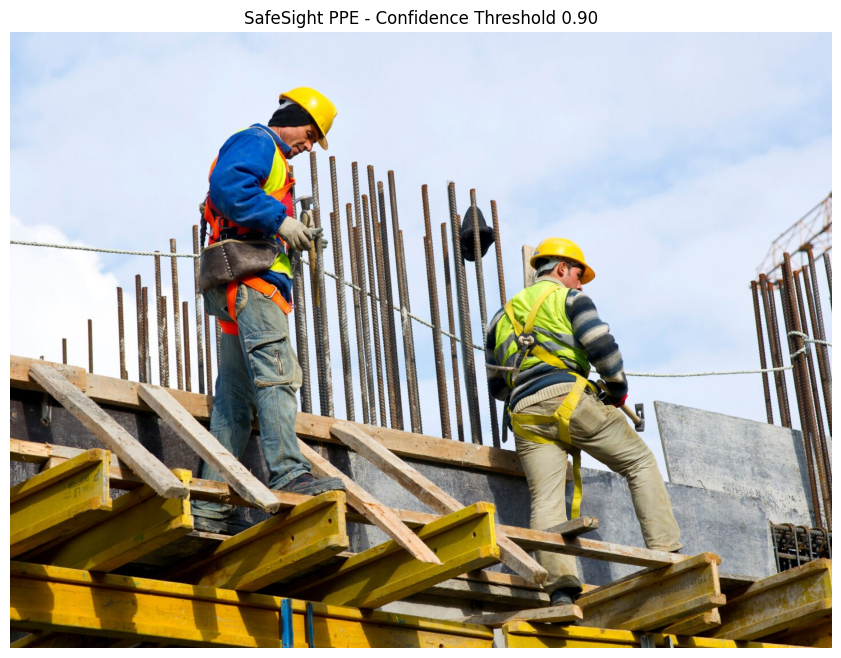

In [7]:
# SafeSight PPE - Confidence Threshold Test

high_conf_results = model(image_path, conf=0.90)

high_conf_annotated = high_conf_results[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(high_conf_annotated[..., ::-1])
plt.axis("off")
plt.title("SafeSight PPE - Confidence Threshold 0.90")
plt.show()

In [8]:
# SafeSight PPE - Baseline Detection Summary

result = results[0]

person_count = 0

for box in result.boxes:
    class_id = int(box.cls[0])
    class_name = result.names[class_id]

    if class_name == "person":
        person_count += 1

print("SafeSight Baseline Report")
print("-------------------------")
print("Workers detected:", person_count)
print()
print("Note: The baseline YOLO model can detect people,")
print("but it does not yet recognize PPE-specific classes.")

SafeSight Baseline Report
-------------------------
Workers detected: 2

Note: The baseline YOLO model can detect people,
but it does not yet recognize PPE-specific classes.


In [9]:
# SafeSight PPE - Upload and Extract Dataset

from google.colab import files
import zipfile
import os

# Upload the Roboflow dataset ZIP
uploaded = files.upload()

# Get the uploaded ZIP filename
zip_name = next(iter(uploaded))

# Create a folder for the extracted dataset
dataset_dir = "/content/safesight_dataset"
os.makedirs(dataset_dir, exist_ok=True)

# Extract the dataset
with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall(dataset_dir)

print("Dataset extracted to:", dataset_dir)

# Search for data.yaml
for root, dirs, filenames in os.walk(dataset_dir):
    if "data.yaml" in filenames:
        print("Found data.yaml:", os.path.join(root, "data.yaml"))

Saving Construction-Site-Safety.v27-yolov8.zip to Construction-Site-Safety.v27-yolov8.zip
Dataset extracted to: /content/safesight_dataset


In [10]:
# SafeSight PPE - Inspect Dataset Configuration

import os
import yaml

yaml_path = None

# Find data.yaml inside the extracted dataset
for root, dirs, files_in_folder in os.walk("/content/safesight_dataset"):
    if "data.yaml" in files_in_folder:
        yaml_path = os.path.join(root, "data.yaml")
        break

if yaml_path:
    print("Found data.yaml:", yaml_path)

    with open(yaml_path, "r") as file:
        data_config = yaml.safe_load(file)

    print("\nDataset configuration:")
    print(data_config)
else:
    print("data.yaml was not found.")

data.yaml was not found.


In [11]:
# SafeSight PPE - Inspect Extracted Dataset Files

import os

base_dir = "/content/safesight_dataset"

for root, dirs, files_in_folder in os.walk(base_dir):
    level = root.replace(base_dir, "").count(os.sep)
    indent = "  " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file_name in files_in_folder[:10]:
        print(f"{indent}  {file_name}")

    # Keep the output manageable
    if level >= 2:
        dirs[:] = []

safesight_dataset/
  css-data/
    README.roboflow.txt
    README.dataset.txt
    valid/
    test/
    train/
  source_files/
    source_files/
      images.jfif
      two-young-construction-workers-wearing-555864.jpg
      hardhat.mp4
      download.jfif
      portrait-of-woman-with-mask-and-man-with-safety-glasses-on-a-construction-HX01FH.jpg
      JapanPPE.mp4
      schupan_japan1web.jpg
      construction-safety.jpg
      indianworkers.mp4
  results_yolov8n_100e/
    kaggle/


In [12]:
# SafeSight PPE - Inspect Dataset Split Structure

import os

base_dir = "/content/safesight_dataset/css-data"

for split in ["train", "valid", "test"]:
    split_path = os.path.join(base_dir, split)

    print(f"\n--- {split.upper()} ---")

    if os.path.exists(split_path):
        print("Folders:", os.listdir(split_path)[:10])

        for item in os.listdir(split_path):
            item_path = os.path.join(split_path, item)

            if os.path.isdir(item_path):
                files = os.listdir(item_path)
                print(f"{item}: {len(files)} files")
                print("Sample files:", files[:3])
    else:
        print("Folder not found.")


--- TRAIN ---
Folders: ['labels', 'images']
labels: 2605 files
Sample files: ['image_622_jpg.rf.1b8c8b100526f72f09884c1cec3c43c5.txt', 'construction-1099-_jpg.rf.bb495a41d6ea301e0032d76b262640dd.txt', 'IMG_3100_mp4-15_jpg.rf.76fab6fd46f346e7c54cbe7871091557.txt']
images: 2605 files
Sample files: ['youtube-344_jpg.rf.b41be0bf431033cf33fa8c7a8cbe924b.jpg', 'construction-1-_mp4-46_jpg.rf.4ba287f4dd6fff9aadf4b49e0171de48.jpg', 'youtube-64_jpg.rf.ee045f5e9670d7422490492b71801bac.jpg']

--- VALID ---
Folders: ['labels', 'images']
labels: 114 files
Sample files: ['autox4_mp4-72_jpg.rf.5e9c1836f027bf40eb8898e68f2efdeb.txt', 'youtube-584_jpg.rf.3136186a0786384c1ffc261f4d40ea42.txt', '518_jpg.rf.73999663994434126ac8b7ac5dbe6b52.txt']
images: 114 files
Sample files: ['youtube-391_jpg.rf.2744ad86e8dbd4366f1fa839accc48b3.jpg', 'IMG_3100_mp4-3_jpg.rf.f05ef399880b1ac30e900df4f2fbb3c0.jpg', 'youtube-232_jpg.rf.f92f310106a11e01495ce8bfae0f9b5a.jpg']

--- TEST ---
Folders: ['labels', 'images']
labels: 

In [13]:
# SafeSight PPE - Inspect Dataset Metadata

base_dir = "/content/safesight_dataset/css-data"

for filename in ["README.dataset.txt", "README.roboflow.txt"]:
    file_path = os.path.join(base_dir, filename)

    print("\n" + "=" * 50)
    print(filename)
    print("=" * 50)

    if os.path.exists(file_path):
        with open(file_path, "r", encoding="utf-8", errors="ignore") as file:
            print(file.read())
    else:
        print("File not found.")


README.dataset.txt
# Construction Site Safety > YOLOv5s
https://universe.roboflow.com/roboflow-universe-projects/construction-site-safety

Provided by a Roboflow user
License: CC BY 4.0

videos from:
* https://www.youtube.com/watch?v=Dhxf5mm7g1g
* https://www.youtube.com/watch?v=rYv9JZ2XBW4

images cloned from:
* https://universe.roboflow.com/roboflow-universe-projects/personal-protective-equipment-combined-model/
* https://universe.roboflow.com/roboflow-universe-projects/people-and-ladders/
* https://universe.roboflow.com/roboflow-universe-projects/safety-vests/
* https://universe.roboflow.com/mohamed-sabek-6zmr6/excavators-cwlh0
* https://universe.roboflow.com/popular-benchmarks/mit-indoor-scene-recognition/ - null images
* https://universe.roboflow.com/mohamed-traore-2ekkp/people-detection-general
* https://universe.roboflow.com/labeler-projects/construction-madness/

README.roboflow.txt

Construction Site Safety - v28 YOLOv5s

This dataset was exported via roboflow.com on February

In [14]:
# SafeSight PPE - Search for Class Names / Dataset Metadata

import os

base_dir = "/content/safesight_dataset"

keywords = [
    "Hardhat",
    "NO-Hardhat",
    "Safety Vest",
    "NO-Safety Vest",
    "Person",
    "names:",
    "nc:"
]

for root, dirs, files_in_folder in os.walk(base_dir):
    for file_name in files_in_folder:
        if file_name.endswith((".txt", ".yaml", ".yml", ".json")):
            file_path = os.path.join(root, file_name)

            try:
                with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                    content = f.read()

                if any(keyword in content for keyword in keywords):
                    print("\nFILE:", file_path)

                    for line in content.splitlines():
                        if any(keyword in line for keyword in keywords):
                            print(line)

            except:
                pass


FILE: /content/safesight_dataset/results_yolov8n_100e/kaggle/working/ppe_data.yaml
{names: [Hardhat, Mask, NO-Hardhat, NO-Mask, NO-Safety Vest, Person, Safety Cone,
    Safety Vest, machinery, vehicle], nc: 10, test: /kaggle/input/construction-site-safety-image-dataset-roboflow/test,


In [15]:
# Check which numeric class IDs actually appear in the labels

from collections import Counter

class_counts = Counter()

labels_dir = "/content/safesight_dataset/css-data/train/labels"

for file_name in os.listdir(labels_dir):
    if file_name.endswith(".txt"):
        file_path = os.path.join(labels_dir, file_name)

        with open(file_path, "r") as f:
            for line in f:
                parts = line.strip().split()

                if parts:
                    class_id = int(parts[0])
                    class_counts[class_id] += 1

print("\nClass IDs found in training labels:")
for class_id in sorted(class_counts):
    print(f"Class {class_id}: {class_counts[class_id]} annotations")


Class IDs found in training labels:
Class 0: 3145 annotations
Class 1: 1651 annotations
Class 2: 2317 annotations
Class 3: 3097 annotations
Class 4: 3962 annotations
Class 5: 9532 annotations
Class 6: 3366 annotations
Class 7: 3033 annotations
Class 8: 5247 annotations
Class 9: 1545 annotations


In [16]:
# SafeSight PPE - Create Local Dataset Configuration

import yaml
import os

dataset_root = "/content/safesight_dataset/css-data"

data_yaml = {
    "path": dataset_root,
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 10,
    "names": [
        "Hardhat",
        "Mask",
        "NO-Hardhat",
        "NO-Mask",
        "NO-Safety Vest",
        "Person",
        "Safety Cone",
        "Safety Vest",
        "machinery",
        "vehicle"
    ]
}

yaml_path = os.path.join(dataset_root, "data.yaml")

with open(yaml_path, "w") as file:
    yaml.safe_dump(data_yaml, file, sort_keys=False)

print("Created:", yaml_path)
print()

with open(yaml_path, "r") as file:
    print(file.read())

Created: /content/safesight_dataset/css-data/data.yaml

path: /content/safesight_dataset/css-data
train: train/images
val: valid/images
test: test/images
nc: 10
names:
- Hardhat
- Mask
- NO-Hardhat
- NO-Mask
- NO-Safety Vest
- Person
- Safety Cone
- Safety Vest
- machinery
- vehicle



### Understanding Check — Dataset Configuration

**What does this section do?**  
This section creates the `data.yaml` file that tells YOLO where the training, validation, and test images are located and maps each numeric class ID to its correct label.

**Why did I keep all 10 dataset classes instead of only the five used by SafeSight?**  
The existing annotation files use class IDs from 0 through 9. Removing classes without also remapping every label could cause YOLO to interpret an annotation as the wrong object. I can train on all 10 classes and have the SafeSight application focus only on the PPE classes it needs.

**What would happen if I changed the order of the class names?**  
The annotation numbers would no longer match the correct class names, so the model could learn incorrect labels. For example, an object labeled as class 5 must continue to mean `Person`.

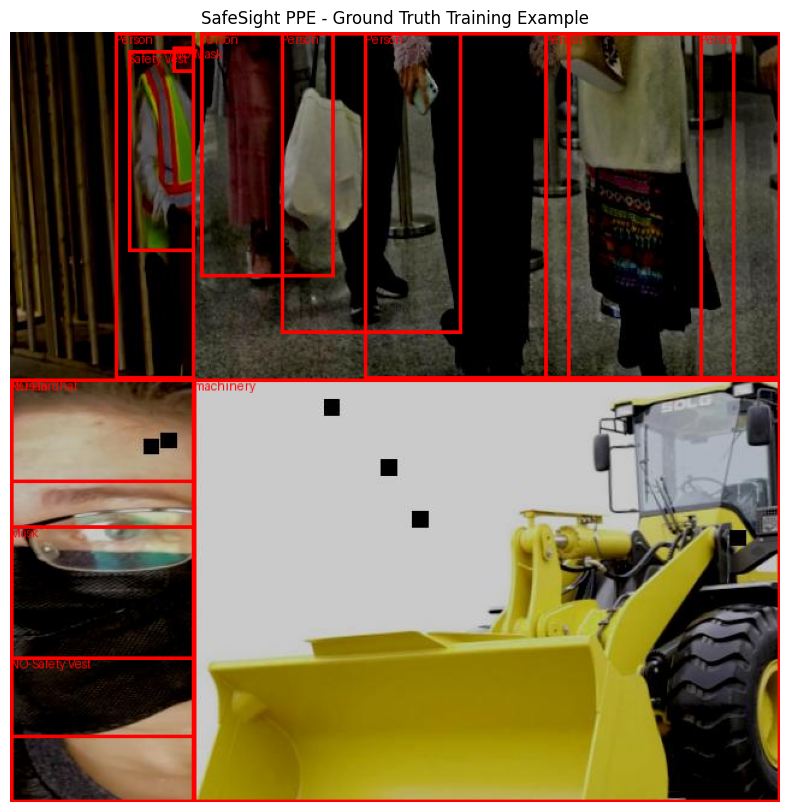

Image: youtube-622_jpg.rf.c2168764d6c0902f3aeeda7ea0706c24.jpg
Label file: youtube-622_jpg.rf.c2168764d6c0902f3aeeda7ea0706c24.txt


In [17]:
# SafeSight PPE - Visualize One Ground-Truth Training Image

import os
import random
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

images_dir = "/content/safesight_dataset/css-data/train/images"
labels_dir = "/content/safesight_dataset/css-data/train/labels"

class_names = [
    "Hardhat",
    "Mask",
    "NO-Hardhat",
    "NO-Mask",
    "NO-Safety Vest",
    "Person",
    "Safety Cone",
    "Safety Vest",
    "machinery",
    "vehicle"
]

# Pick one random training image
image_file = random.choice(os.listdir(images_dir))
image_path_check = os.path.join(images_dir, image_file)

# Find its matching label file
label_file = os.path.splitext(image_file)[0] + ".txt"
label_path = os.path.join(labels_dir, label_file)

# Open the image
image_check = Image.open(image_path_check).convert("RGB")
draw = ImageDraw.Draw(image_check)

width, height = image_check.size

# Draw ground-truth labels
with open(label_path, "r") as file:
    for line in file:
        class_id, x_center, y_center, box_width, box_height = map(float, line.split())

        class_id = int(class_id)

        # Convert YOLO normalized coordinates to pixel coordinates
        x1 = (x_center - box_width / 2) * width
        y1 = (y_center - box_height / 2) * height
        x2 = (x_center + box_width / 2) * width
        y2 = (y_center + box_height / 2) * height

        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
        draw.text((x1, y1), class_names[class_id], fill="red")

plt.figure(figsize=(10, 10))
plt.imshow(image_check)
plt.axis("off")
plt.title("SafeSight PPE - Ground Truth Training Example")
plt.show()

print("Image:", image_file)
print("Label file:", label_file)

In [18]:
# SafeSight PPE - Fine-Tune YOLO11n

from ultralytics import YOLO

# Start from the same pretrained YOLO11 Nano model
ppe_model = YOLO("yolo11n.pt")

training_results = ppe_model.train(
    data="/content/safesight_dataset/css-data/data.yaml",
    epochs=25,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/safesight_runs",
    name="yolo11n_ppe_25e",
    patience=7,
    plots=True
)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/safesight_dataset/css-data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_ppe_25e, nbs=64, nms=None, opset=No

### Understanding Check — PPE Model Fine-Tuning

**What does this section do?**  
This section fine-tunes a pretrained YOLO11n model on the Construction Site Safety dataset. Instead of training from scratch, the model starts with pretrained weights and learns the 10 PPE and construction-related classes in my dataset.

**Why did I use `best.pt` instead of only the final epoch?**  
YOLO evaluates the model on the validation set during training and saves the checkpoint that performed best. The final epoch is not always the strongest model, so `best.pt` is the checkpoint I will use for testing and the SafeSight application.

**What would happen if I trained for more epochs?**  
More epochs could improve the model if it is still learning, but they could also cause overfitting where performance improves on the training data without improving on unseen images. I would need to compare evaluation results instead of assuming that more training is automatically better.

In [19]:
# SafeSight PPE - Final Test Set Evaluation

from ultralytics import YOLO

best_model_path = "/content/safesight_runs/yolo11n_ppe_25e/weights/best.pt"

# Load the best checkpoint from training
best_model = YOLO(best_model_path)

# Evaluate only on the held-out test split
test_results = best_model.val(
    data="/content/safesight_dataset/css-data/data.yaml",
    split="test",
    imgsz=640,
    device=0,
    plots=True,
    project="/content/safesight_runs",
    name="test_evaluation"
)

print("\nSafeSight Test Results")
print("----------------------")
print(f"Precision: {test_results.box.mp:.3f}")
print(f"Recall: {test_results.box.mr:.3f}")
print(f"mAP50: {test_results.box.map50:.3f}")
print(f"mAP50-95: {test_results.box.map:.3f}")
print("Speed:", test_results.speed)

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,584,102 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1749.3±601.7 MB/s, size: 53.7 KB)
val: Scanning /content/safesight_dataset/css-data/test/labels... 82 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 82/82 2.1Kit/s 0.0s
val: New cache created: /content/safesight_dataset/css-data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.6it/s 3.8s
                   all         82        760      0.797      0.636      0.692      0.385
               Hardhat         30        110      0.973      0.755       0.87      0.506
                  Mask         16         28      0.951      0.695      0.758      0.435
            NO-Hardhat         25         41       0.78      0.512      0.536       0.25
               NO-Mask         30         79      

### Understanding Check — Final Test Evaluation

**What does this section do?**  
This section evaluates the best trained SafeSight model on the held-out test set that was not used for training or model selection. This gives me a more honest estimate of how the model performs on unseen data.

**How did the model compare to my Blueprint targets?**  
My Blueprint target was an mAP50 of at least 0.70, and the model achieved 0.692 on the test set, so it missed the target by a small amount. My speed target was under one second per image, and the model averaged about 7 milliseconds of inference time, so it exceeded the speed goal.

**What do the class-level results show?**  
The model performed better on visible PPE such as hard hats and safety vests than on some missing-PPE classes. NO-Hardhat was one of the weaker classes, which means SafeSight should flag results for human review instead of treating every detection as a final safety decision.


image 1/1 /content/1280x720_21_A-1440x1080 (1).jpg: 480x640 2 Hardhats, 2 NO-Masks, 2 NO-Safety Vests, 2 Persons, 2 Safety Vests, 8.2ms
Speed: 2.2ms preprocess, 8.2ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


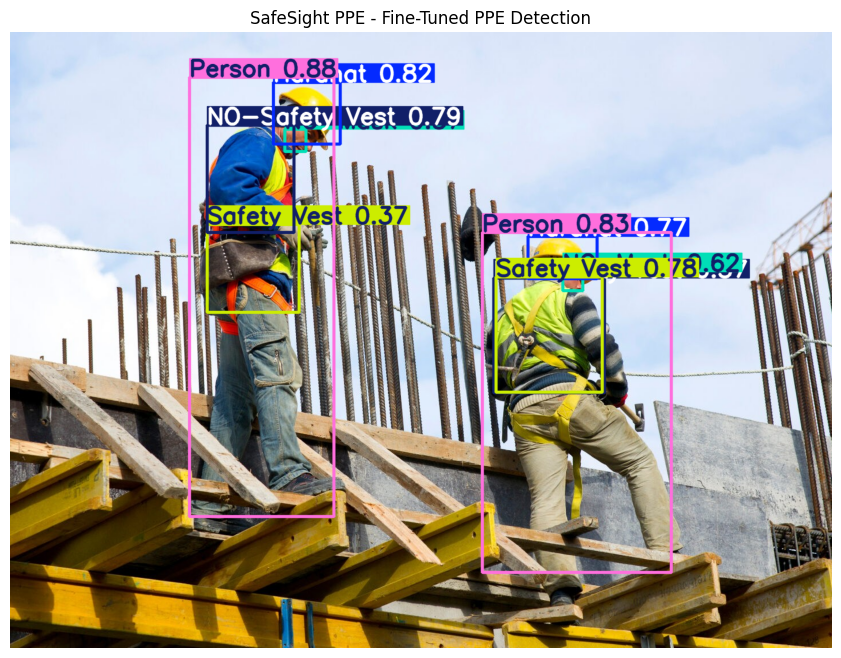

In [20]:
# SafeSight PPE - Run Fine-Tuned Model on Construction Image

# Run the trained PPE model on the same image used for the baseline
ppe_results = best_model(image_path, conf=0.25)

# Create annotated output
ppe_annotated = ppe_results[0].plot()

# Display with correct RGB colors
plt.figure(figsize=(12, 8))
plt.imshow(ppe_annotated[..., ::-1])
plt.axis("off")
plt.title("SafeSight PPE - Fine-Tuned PPE Detection")
plt.show()

### Understanding Check — Fine-Tuned PPE Detection

**What changed compared with the baseline model?**  
The baseline YOLO model only detected the two workers as people. After fine-tuning, the model can also detect PPE-specific classes such as Hardhat, Safety Vest, and NO-Safety Vest.

**What problem appeared in this test?**  
The model detected both Safety Vest and NO-Safety Vest on the same image even though the workers appear to be wearing safety vests. This shows that fine-tuning improved the model's PPE awareness, but the detections are not always reliable.

**Why does SafeSight use human review instead of making a final safety decision?**  
A false positive like the NO-Safety Vest detections could incorrectly flag a worker as noncompliant. SafeSight should therefore treat these detections as possible violations that require human review.

In [49]:
# SafeSight PPE - Compliance Review Logic

from collections import Counter

result = ppe_results[0]

# Classes used by SafeSight
safesight_classes = [
    "Person",
    "Hardhat",
    "NO-Hardhat",
    "Safety Vest",
    "NO-Safety Vest"
]

# Count detections
detection_counts = Counter()

for box in result.boxes:
    class_id = int(box.cls[0])
    class_name = result.names[class_id]

    if class_name in safesight_classes:
        detection_counts[class_name] += 1

# Pull out the counts we care about
workers = detection_counts["Person"]
hardhats = detection_counts["Hardhat"]
no_hardhats = detection_counts["NO-Hardhat"]
safety_vests = detection_counts["Safety Vest"]
no_safety_vests = detection_counts["NO-Safety Vest"]

# Simple compliance rule from the SafeSight Blueprint
if no_hardhats > 0 or no_safety_vests > 0:
    status = "REVIEW REQUIRED"
else:
    status = "NO PPE VIOLATIONS DETECTED"

print("SafeSight PPE Compliance Report")
print("--------------------------------")
print("Workers detected:", workers)
print("Hard hats detected:", hardhats)
print("Safety vests detected:", safety_vests)
print()
print("Possible violations:")
print("Missing hard hats:", no_hardhats)
print("Missing safety vests:", no_safety_vests)
print()
print("Status:", status)

SafeSight PPE Compliance Report
--------------------------------
Workers detected: 2
Hard hats detected: 2
Safety vests detected: 2

Possible violations:
Missing hard hats: 0
Missing safety vests: 2

Status: REVIEW REQUIRED


### Understanding Check — Compliance Review Logic

**What does this section do?**  
This section converts the model's raw PPE detections into a simple SafeSight compliance report. It counts workers, hard hats, safety vests, and possible missing PPE, then assigns an overall review status.

**Why does this image show REVIEW REQUIRED?**  
The model detected two NO-Safety Vest instances, so the compliance rule flagged the image for review. Visually, the workers appear to be wearing safety vests, which means these are likely false-positive detections.

**What would happen if there were no NO-Hardhat or NO-Safety Vest detections?**  
The status would change to NO PPE VIOLATIONS DETECTED. This does not guarantee that the site is safe; it only means the model did not detect the PPE violations SafeSight is currently checking for.

In [52]:
# SafeSight PPE - Reusable Analysis Function with Conflict Checks

from collections import Counter
import matplotlib.pyplot as plt

def analyze_ppe(image_path, confidence=0.25):
    """
    Run SafeSight PPE detection and produce:
    1. An annotated image
    2. A compliance review summary
    3. Detection-conflict warnings
    """

    # Run the trained PPE model
    results = best_model(image_path, conf=confidence)
    result = results[0]

    # Display annotated image
    annotated = result.plot()

    plt.figure(figsize=(12, 8))
    plt.imshow(annotated[..., ::-1])
    plt.axis("off")
    plt.title("SafeSight PPE Compliance Review")
    plt.show()

    # Classes used by SafeSight
    safesight_classes = [
        "Person",
        "Hardhat",
        "NO-Hardhat",
        "Safety Vest",
        "NO-Safety Vest"
    ]

    # Count relevant detections
    counts = Counter()

    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = result.names[class_id]

        if class_name in safesight_classes:
            counts[class_name] += 1

    workers = counts["Person"]
    hardhats = counts["Hardhat"]
    no_hardhats = counts["NO-Hardhat"]
    safety_vests = counts["Safety Vest"]
    no_safety_vests = counts["NO-Safety Vest"]

    # Look for suspicious or contradictory totals
    conflict_notes = []

    if workers > 0 and (hardhats + no_hardhats) > workers:
        conflict_notes.append(
            "Hardhat detections may contain duplicates or conflicting predictions."
        )

    if workers > 0 and (safety_vests + no_safety_vests) > workers:
        conflict_notes.append(
            "Safety vest detections may contain duplicates or conflicting predictions."
        )

    # Explicit negative PPE detections
    explicit_violation = (
        no_hardhats > 0 or
        no_safety_vests > 0
    )

    # Check whether there is enough positive PPE evidence
    incomplete_coverage = False

    if workers > 0:
        if hardhats < workers:
            conflict_notes.append(
                "Not every detected worker has a corresponding Hardhat detection."
            )
            incomplete_coverage = True

        if safety_vests < workers:
            conflict_notes.append(
                "Not every detected worker has a corresponding Safety Vest detection."
            )
            incomplete_coverage = True

    # Final review status
    if explicit_violation or incomplete_coverage or conflict_notes:
        status = "REVIEW REQUIRED"
    else:
        status = "NO PPE VIOLATIONS DETECTED"

    # Print report
    print("\nSafeSight PPE Compliance Report")
    print("--------------------------------")
    print("Workers detected:", workers)
    print("Hard hats detected:", hardhats)
    print("Safety vests detected:", safety_vests)

    print("\nExplicit missing-PPE detections:")
    print("NO-Hardhat detections:", no_hardhats)
    print("NO-Safety Vest detections:", no_safety_vests)

    if conflict_notes:
        print("\nReview warnings:")
        for note in conflict_notes:
            print("-", note)

    print("\nStatus:", status)

    return result


image 1/1 /content/1280x720_21_A-1440x1080 (1).jpg: 480x640 2 Hardhats, 2 NO-Masks, 2 NO-Safety Vests, 2 Persons, 2 Safety Vests, 10.8ms
Speed: 2.3ms preprocess, 10.8ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)


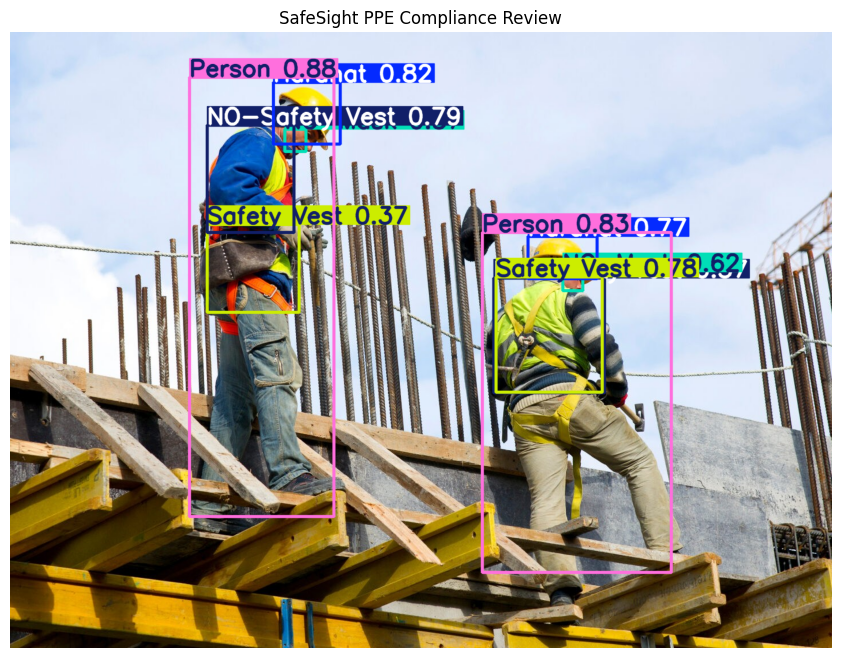


SafeSight PPE Compliance Report
--------------------------------
Workers detected: 2
Hard hats detected: 2
Safety vests detected: 2

Explicit missing-PPE detections:
NO-Hardhat detections: 0
NO-Safety Vest detections: 2

Review warnings:
- Safety vest detections may contain duplicates or conflicting predictions.

Status: REVIEW REQUIRED


In [53]:
# Run SafeSight on the current construction image
result = analyze_ppe(image_path)

Saving Denver-Post-Top-Workplace-1200-x-675-px-1.png to Denver-Post-Top-Workplace-1200-x-675-px-1 (1).png
Testing image: Denver-Post-Top-Workplace-1200-x-675-px-1 (1).png

image 1/1 /content/Denver-Post-Top-Workplace-1200-x-675-px-1 (1).png: 384x640 4 Hardhats, 1 NO-Mask, 3 Persons, 3 Safety Vests, 42.8ms
Speed: 10.5ms preprocess, 42.8ms inference, 5.8ms postprocess per image at shape (1, 3, 384, 640)


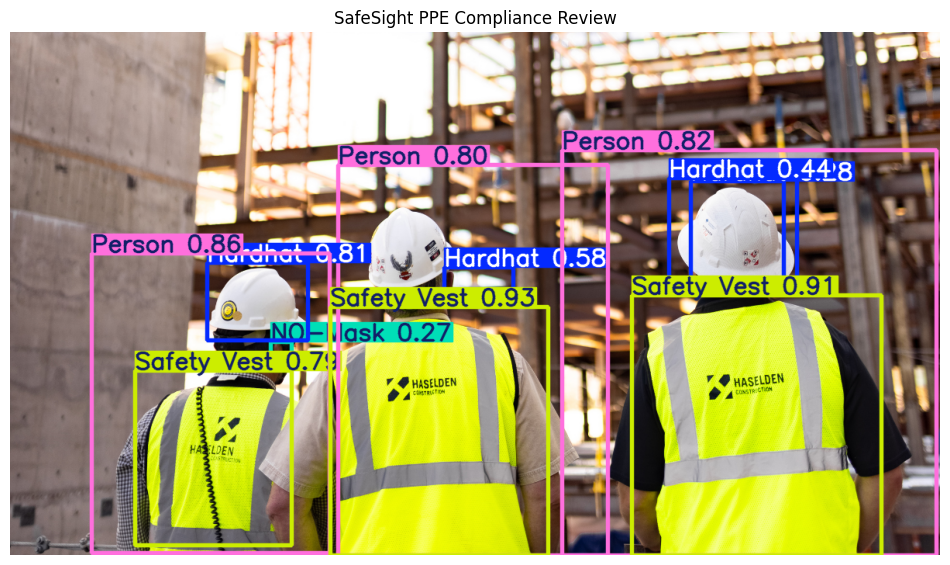


SafeSight PPE Compliance Report
--------------------------------
Workers detected: 3
Hard hats detected: 4
Safety vests detected: 3

Explicit missing-PPE detections:
NO-Hardhat detections: 0
NO-Safety Vest detections: 0

Review warnings:
- Hardhat detections may contain duplicates or conflicting predictions.

Status: REVIEW REQUIRED


In [54]:
# SafeSight PPE - Test on a New Construction Image

from google.colab import files

uploaded_test = files.upload()

# Keep this separate from the original baseline image
new_test_path = next(iter(uploaded_test))

print("Testing image:", new_test_path)

new_test_result = analyze_ppe(new_test_path)

### Test Case 1 — Compliant PPE

This image shows three workers who appear to be wearing hard hats and safety vests. SafeSight detected 3 people, 3 safety vests, and no explicit NO-Hardhat or NO-Safety Vest detections.

However, the model detected 4 hard hats even though only 3 workers are visible. SafeSight treated this as a possible duplicate or conflicting detection and returned REVIEW REQUIRED.

This example shows that even when an image appears compliant, unusual detection counts should still be reviewed by a person rather than automatically treated as a confirmed pass.

Saving construction-worker-welding-without-a-protection-mask-E1M4NG.jpg to construction-worker-welding-without-a-protection-mask-E1M4NG (2).jpg
Testing image: construction-worker-welding-without-a-protection-mask-E1M4NG (2).jpg

image 1/1 /content/construction-worker-welding-without-a-protection-mask-E1M4NG (2).jpg: 480x640 1 NO-Safety Vest, 1 Person, 2 Safety Cones, 13.1ms
Speed: 2.6ms preprocess, 13.1ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)


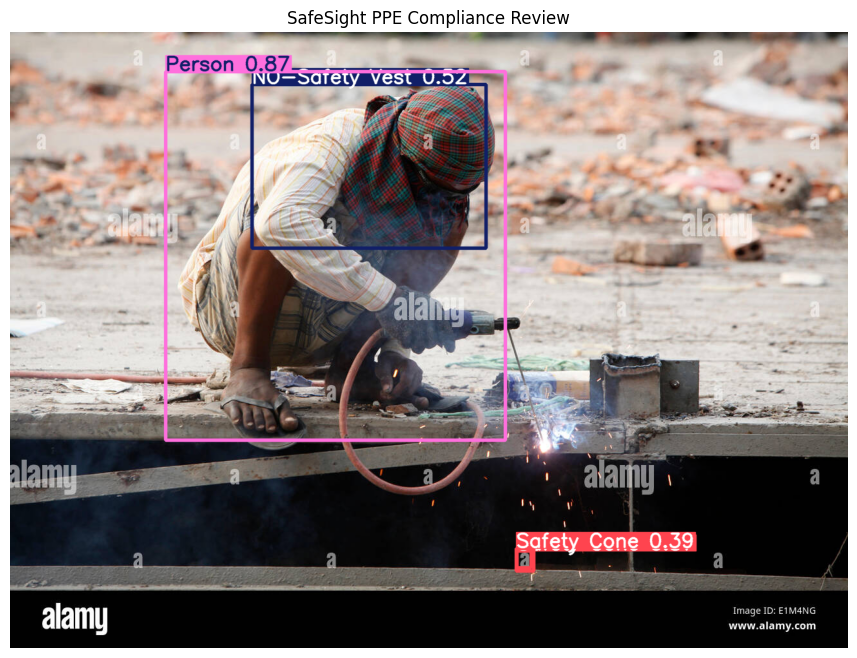


SafeSight PPE Compliance Report
--------------------------------
Workers detected: 1
Hard hats detected: 0
Safety vests detected: 0

Explicit missing-PPE detections:
NO-Hardhat detections: 0
NO-Safety Vest detections: 1

Review warnings:
- Not every detected worker has a corresponding Hardhat detection.
- Not every detected worker has a corresponding Safety Vest detection.

Status: REVIEW REQUIRED


In [55]:
# SafeSight PPE - Test a Possible PPE Violation

from google.colab import files

uploaded_violation = files.upload()

violation_image_path = next(iter(uploaded_violation))

print("Testing image:", violation_image_path)

violation_result = analyze_ppe(violation_image_path)

### Test Case 2 — PPE Violation

This image contains one worker who appears to be missing both a hard hat and a safety vest. SafeSight correctly detected the missing safety vest and returned REVIEW REQUIRED.

However, the model did not detect the missing hard hat, even though no hard hat is visible. This matches the weaker NO-Hardhat performance seen in the test-set metrics and shows why SafeSight should be used as a human-review tool rather than an automatic safety decision system.

Saving 4b434b7e0000000000a62352.webp to 4b434b7e0000000000a62352 (2).webp
Testing image: 4b434b7e0000000000a62352 (2).webp

image 1/1 /content/4b434b7e0000000000a62352 (2).webp: 480x640 1 Hardhat, 1 NO-Hardhat, 1 NO-Mask, 1 Person, 2 Safety Cones, 1 Safety Vest, 8.7ms
Speed: 1.7ms preprocess, 8.7ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


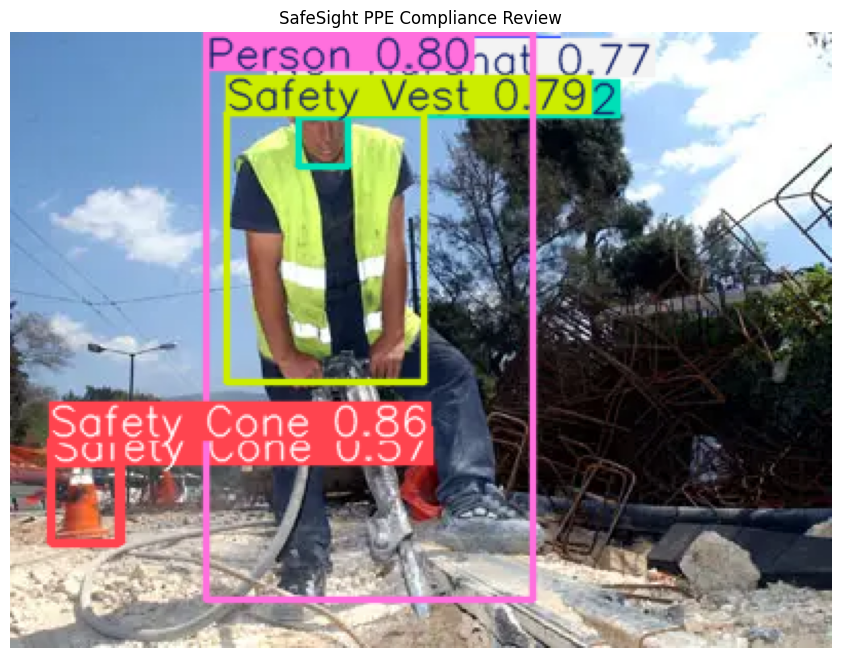


SafeSight PPE Compliance Report
--------------------------------
Workers detected: 1
Hard hats detected: 1
Safety vests detected: 1

Explicit missing-PPE detections:
NO-Hardhat detections: 1
NO-Safety Vest detections: 0

Review warnings:
- Hardhat detections may contain duplicates or conflicting predictions.

Status: REVIEW REQUIRED


In [56]:
# SafeSight PPE - NO-Hardhat Test

from google.colab import files

uploaded_hardhat_test = files.upload()

hardhat_test_path = next(iter(uploaded_hardhat_test))

print("Testing image:", hardhat_test_path)

hardhat_test_result = analyze_ppe(hardhat_test_path)

### Test Case 3 — Missing Hard Hat

This image contains one worker who appears to be wearing a safety vest but not a hard hat. SafeSight detected both NO-Hardhat and Hardhat, which is a contradictory result, but it still returned REVIEW REQUIRED because a missing-hard-hat detection was present.

This test shows that the model can identify missing PPE, but it can also produce conflicting predictions on the same worker. That is another reason the system should support human review instead of making an automatic compliance decision.

### Understanding Check — Detection Conflict Handling

**What does this improvement do?**  
This version of SafeSight checks whether the number of PPE-state detections makes sense compared with the number of detected workers. If the model produces both a Hardhat and NO-Hardhat prediction for one worker, the system adds a warning that the detections may be conflicting or duplicated.

**Why did I add this instead of changing the model's prediction?**  
The application should not pretend to know which prediction is correct when the detector is uncertain. Flagging the conflict keeps the original model evidence visible and sends the case to human review.

**What would happen without this check?**  
SafeSight could report contradictory counts without explaining that something is wrong, which could make the compliance summary look more reliable than it actually is.


image 1/1 /content/Denver-Post-Top-Workplace-1200-x-675-px-1 (1).png: 384x640 4 Hardhats, 1 NO-Mask, 3 Persons, 3 Safety Vests, 9.4ms
Speed: 1.7ms preprocess, 9.4ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


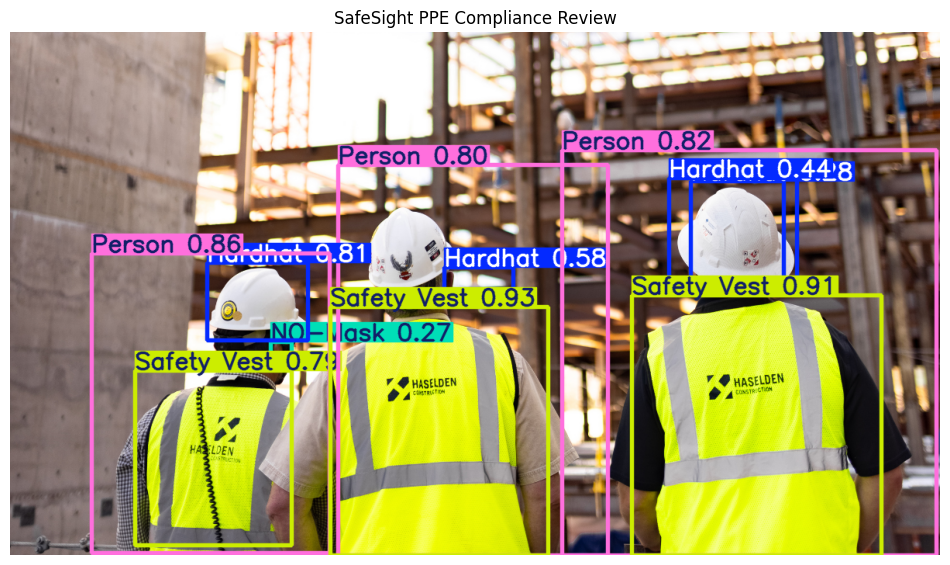


SafeSight PPE Compliance Report
--------------------------------
Workers detected: 3
Hard hats detected: 4
Safety vests detected: 3

Explicit missing-PPE detections:
NO-Hardhat detections: 0
NO-Safety Vest detections: 0

Review warnings:
- Hardhat detections may contain duplicates or conflicting predictions.

Status: REVIEW REQUIRED


In [57]:
# Re-test the compliant PPE example
compliant_result = analyze_ppe(new_test_path)


image 1/1 /content/construction-worker-welding-without-a-protection-mask-E1M4NG (2).jpg: 480x640 1 NO-Safety Vest, 1 Person, 2 Safety Cones, 10.0ms
Speed: 2.1ms preprocess, 10.0ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


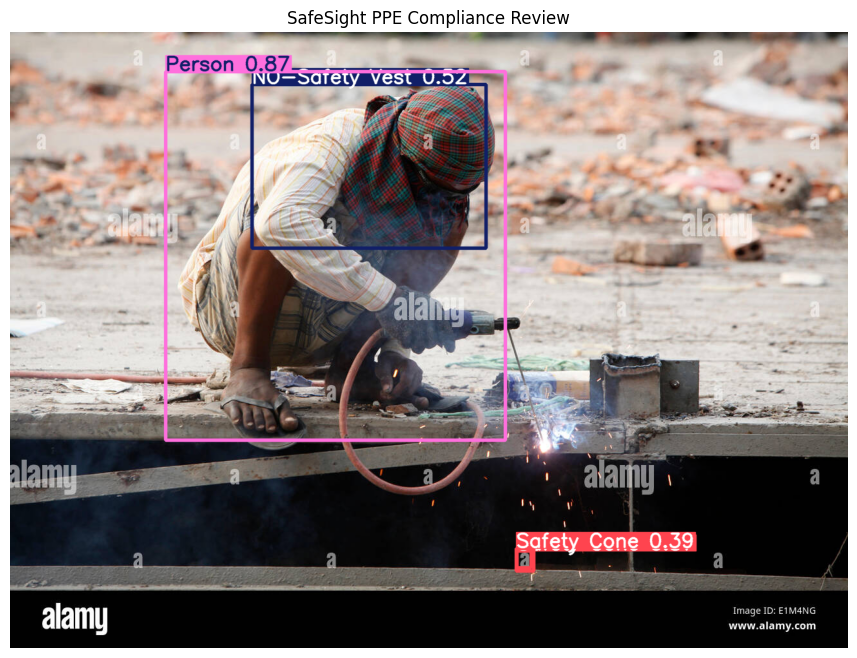


SafeSight PPE Compliance Report
--------------------------------
Workers detected: 1
Hard hats detected: 0
Safety vests detected: 0

Explicit missing-PPE detections:
NO-Hardhat detections: 0
NO-Safety Vest detections: 1

Review warnings:
- Not every detected worker has a corresponding Hardhat detection.
- Not every detected worker has a corresponding Safety Vest detection.

Status: REVIEW REQUIRED


In [58]:
# Re-test the PPE violation example
violation_result = analyze_ppe(violation_image_path)

In [59]:
# SafeSight PPE - Back Up Model and Results to Google Drive

from google.colab import drive
import os
import shutil

# Mount Google Drive
drive.mount("/content/drive")

# Create a SafeSight backup folder
backup_dir = "/content/drive/MyDrive/SafeSight_PPE"
os.makedirs(backup_dir, exist_ok=True)

# Save the trained model
best_model_source = "/content/safesight_runs/yolo11n_ppe_25e/weights/best.pt"
best_model_backup = os.path.join(backup_dir, "best.pt")

shutil.copy2(best_model_source, best_model_backup)

# Save the dataset configuration
yaml_source = "/content/safesight_dataset/css-data/data.yaml"
yaml_backup = os.path.join(backup_dir, "data.yaml")

shutil.copy2(yaml_source, yaml_backup)

# Save training and evaluation outputs
runs_backup = os.path.join(backup_dir, "safesight_runs")

if os.path.exists(runs_backup):
    shutil.rmtree(runs_backup)

shutil.copytree("/content/safesight_runs", runs_backup)

print("Backup complete.")
print("Model:", best_model_backup)
print("Dataset config:", yaml_backup)
print("Training/evaluation results:", runs_backup)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Backup complete.
Model: /content/drive/MyDrive/SafeSight_PPE/best.pt
Dataset config: /content/drive/MyDrive/SafeSight_PPE/data.yaml
Training/evaluation results: /content/drive/MyDrive/SafeSight_PPE/safesight_runs


In [60]:
# SafeSight PPE - Save Final Result Examples

import os
from PIL import Image

results_dir = "/content/drive/MyDrive/SafeSight_PPE/results"
os.makedirs(results_dir, exist_ok=True)

def save_annotated_result(result, filename):
    annotated = result.plot()

    # Convert BGR to RGB before saving
    annotated_rgb = annotated[..., ::-1]

    output_path = os.path.join(results_dir, filename)
    Image.fromarray(annotated_rgb).save(output_path)

    print("Saved:", output_path)


# 1. Compliant PPE example
save_annotated_result(
    compliant_result,
    "compliant_ppe_example.png"
)

# 2. Missing safety vest example
save_annotated_result(
    violation_result,
    "missing_safety_vest_example.png"
)

# 3. Missing hard hat / conflict example
save_annotated_result(
    hardhat_test_result,
    "hardhat_conflict_example.png"
)

Saved: /content/drive/MyDrive/SafeSight_PPE/results/compliant_ppe_example.png
Saved: /content/drive/MyDrive/SafeSight_PPE/results/missing_safety_vest_example.png
Saved: /content/drive/MyDrive/SafeSight_PPE/results/hardhat_conflict_example.png


In [61]:
# SafeSight PPE - Save Final Metrics Summary

import csv
import os

results_dir = "/content/drive/MyDrive/SafeSight_PPE/results"

metrics_path = os.path.join(results_dir, "metrics_summary.csv")

metrics_rows = [
    ["Metric", "Blueprint Target", "Achieved", "Outcome"],
    ["mAP50", ">= 0.70", "0.692", "Missed narrowly"],
    ["Inference Speed", "< 1 second/image", "6.95 ms/image", "Met"],
    ["Precision", "Not specified", "0.797", "Measured"],
    ["Recall", "Not specified", "0.636", "Measured"],
    ["mAP50-95", "Not specified", "0.385", "Measured"]
]

with open(metrics_path, "w", newline="") as file:
    writer = csv.writer(file)
    writer.writerows(metrics_rows)

print("Saved:", metrics_path)

Saved: /content/drive/MyDrive/SafeSight_PPE/results/metrics_summary.csv


Upload a construction-site image for SafeSight review:


Saving construction-site.jpg to construction-site (2).jpg

Analyzing: construction-site (2).jpg

image 1/1 /content/construction-site (2).jpg: 448x640 2 Hardhats, 5 Persons, 6 Safety Vests, 11.2ms
Speed: 2.2ms preprocess, 11.2ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)


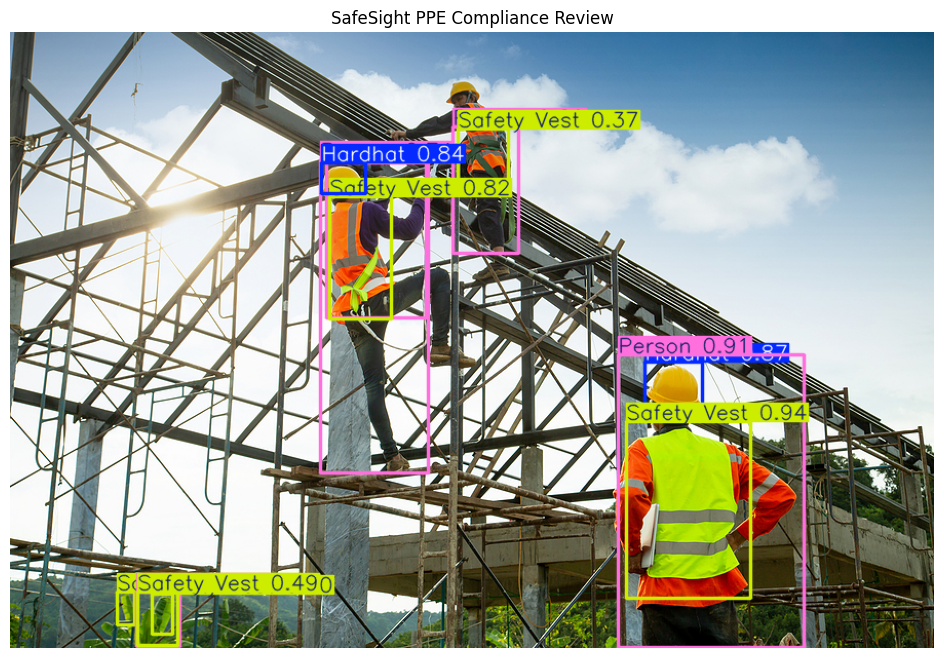


SafeSight PPE Compliance Report
--------------------------------
Workers detected: 5
Hard hats detected: 2
Safety vests detected: 6

Explicit missing-PPE detections:
NO-Hardhat detections: 0
NO-Safety Vest detections: 0

Review warnings:
- Safety vest detections may contain duplicates or conflicting predictions.
- Not every detected worker has a corresponding Hardhat detection.

Status: REVIEW REQUIRED


In [62]:
# SafeSight PPE - Demo Runner

from google.colab import files

print("Upload a construction-site image for SafeSight review:")

demo_upload = files.upload()

demo_image_path = next(iter(demo_upload))

print("\nAnalyzing:", demo_image_path)

demo_result = analyze_ppe(demo_image_path)

### False Positive Observation

In this test image, the model incorrectly classified a bright green plant as a Person. Because of that false Person detection, the model also produced PPE-related detections around the same area.

I first tested whether PPE detections could be filtered by checking whether they appeared inside a detected Person box. That approach did not fully solve the problem because the plant itself had already been incorrectly detected as a Person.

This showed that errors early in the detection pipeline can affect later compliance logic. For the final SafeSight POC, I kept the simpler conflict-aware review logic and treated unusual or incomplete detections as REVIEW REQUIRED instead of automatically assuming compliance.

### Understanding Check — Safer Compliance Logic

**What changed?**  
SafeSight now checks more than just explicit NO-Hardhat and NO-Safety Vest detections. It also compares positive PPE detections with the number of workers and warns when the counts are incomplete or contradictory.

**Why is this safer?**  
A model can fail to detect a missing-PPE class even when PPE is actually missing. If five workers are detected but only two hard hats are found, SafeSight now sends the image for review instead of assuming there is no violation.

**What is the limitation?**  
This is still an aggregate check and does not match each hard hat or vest to a specific worker. The warning means the evidence is incomplete, not that SafeSight knows exactly which worker is missing PPE.

In [63]:
# SafeSight PPE - Test Person-Relative PPE Filtering

result = demo_result

# Collect person bounding boxes
person_boxes = []

for box in result.boxes:
    class_id = int(box.cls[0])
    class_name = result.names[class_id]

    if class_name == "Person":
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        person_boxes.append((x1, y1, x2, y2))


def center_inside_person(box, person_boxes):
    """
    Return True if the center point of a PPE detection
    falls inside at least one detected Person box.
    """

    x1, y1, x2, y2 = box.xyxy[0].tolist()

    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2

    for px1, py1, px2, py2 in person_boxes:
        if px1 <= center_x <= px2 and py1 <= center_y <= py2:
            return True

    return False


ppe_classes = [
    "Hardhat",
    "NO-Hardhat",
    "Safety Vest",
    "NO-Safety Vest"
]

print("Person boxes found:", len(person_boxes))
print()

for box in result.boxes:
    class_id = int(box.cls[0])
    class_name = result.names[class_id]
    confidence = float(box.conf[0])

    if class_name in ppe_classes:
        attached_to_person = center_inside_person(box, person_boxes)

        if attached_to_person:
            decision = "KEEP"
        else:
            decision = "IGNORE"

        print(
            f"{class_name:15} "
            f"confidence={confidence:.2f} "
            f"-> {decision}"
        )

Person boxes found: 5

Safety Vest     confidence=0.94 -> KEEP
Hardhat         confidence=0.87 -> KEEP
Hardhat         confidence=0.84 -> KEEP
Safety Vest     confidence=0.82 -> KEEP
Safety Vest     confidence=0.49 -> KEEP
Safety Vest     confidence=0.40 -> KEEP
Safety Vest     confidence=0.37 -> KEEP
Safety Vest     confidence=0.28 -> IGNORE


In [64]:
# SafeSight PPE - Test Position-Aware PPE Filtering

result = demo_result

# Collect person bounding boxes
person_boxes = []

for box in result.boxes:
    class_id = int(box.cls[0])
    class_name = result.names[class_id]

    if class_name == "Person":
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        person_boxes.append((x1, y1, x2, y2))


def valid_ppe_position(box, class_name, person_boxes):
    """
    Check whether a PPE detection appears in a reasonable
    location relative to at least one detected person.
    """

    x1, y1, x2, y2 = box.xyxy[0].tolist()

    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2

    for px1, py1, px2, py2 in person_boxes:

        person_width = px2 - px1
        person_height = py2 - py1

        # PPE center must first be horizontally inside the person
        if not (px1 <= center_x <= px2):
            continue

        relative_y = (center_y - py1) / person_height

        # Hardhat-related detections should be near the head
        if class_name in ["Hardhat", "NO-Hardhat"]:
            if 0.00 <= relative_y <= 0.40:
                return True

        # Vest-related detections should be around the torso
        elif class_name in ["Safety Vest", "NO-Safety Vest"]:
            if 0.15 <= relative_y <= 0.70:
                return True

    return False


ppe_classes = [
    "Hardhat",
    "NO-Hardhat",
    "Safety Vest",
    "NO-Safety Vest"
]

print("Person boxes found:", len(person_boxes))
print()

for box in result.boxes:
    class_id = int(box.cls[0])
    class_name = result.names[class_id]
    confidence = float(box.conf[0])

    if class_name in ppe_classes:

        valid_position = valid_ppe_position(
            box,
            class_name,
            person_boxes
        )

        decision = "KEEP" if valid_position else "IGNORE"

        print(
            f"{class_name:15} "
            f"confidence={confidence:.2f} "
            f"-> {decision}"
        )

Person boxes found: 5

Safety Vest     confidence=0.94 -> KEEP
Hardhat         confidence=0.87 -> KEEP
Hardhat         confidence=0.84 -> KEEP
Safety Vest     confidence=0.82 -> KEEP
Safety Vest     confidence=0.49 -> KEEP
Safety Vest     confidence=0.40 -> KEEP
Safety Vest     confidence=0.37 -> KEEP
Safety Vest     confidence=0.28 -> IGNORE


Workers found: 5

0: 640x416 1 Hardhat, 1 Person, 1 Safety Vest, 11.2ms
Speed: 1.7ms preprocess, 11.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 416)


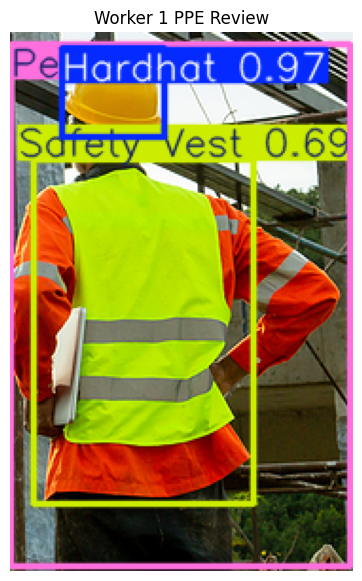


Worker 1 detections:
- Hardhat: 0.97
- Person: 0.89
- Safety Vest: 0.69

0: 640x224 1 Hardhat, 1 Person, 1 Safety Vest, 14.2ms
Speed: 1.1ms preprocess, 14.2ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 224)


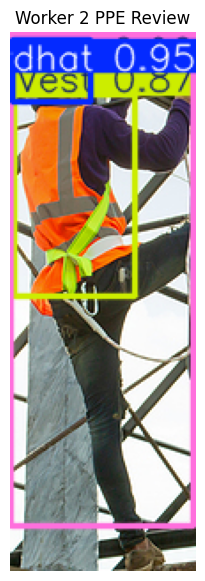


Worker 2 detections:
- Hardhat: 0.95
- Person: 0.90
- Safety Vest: 0.87

0: 640x512 1 Hardhat, 1 Person, 13.3ms
Speed: 1.7ms preprocess, 13.3ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 512)


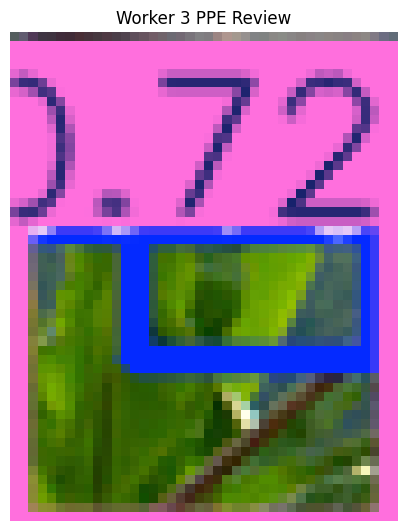


Worker 3 detections:
- Person: 0.72
- Hardhat: 0.46

0: 640x352 1 NO-Hardhat, 3 Persons, 1 Safety Vest, 13.1ms
Speed: 2.2ms preprocess, 13.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 352)


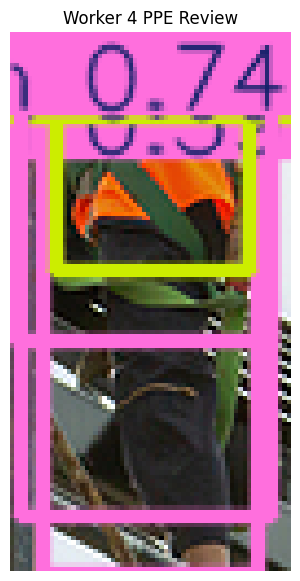


Worker 4 detections:
- Person: 0.74
- Safety Vest: 0.65
- Person: 0.56
- Person: 0.39
- NO-Hardhat: 0.25

0: 640x416 1 Hardhat, 1 NO-Hardhat, 1 NO-Safety Vest, 2 Persons, 2 Safety Vests, 16.3ms
Speed: 1.5ms preprocess, 16.3ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 416)


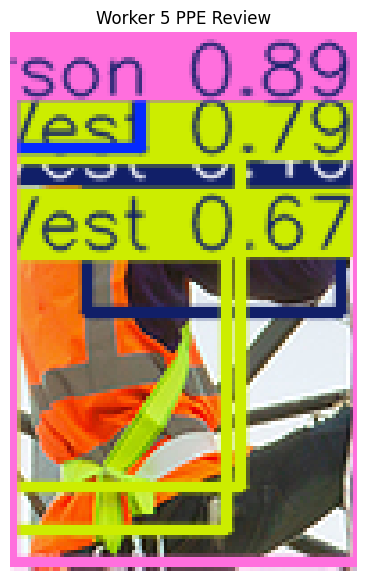


Worker 5 detections:
- Person: 0.89
- Hardhat: 0.85
- Safety Vest: 0.79
- Safety Vest: 0.67
- NO-Safety Vest: 0.40
- NO-Hardhat: 0.29
- Person: 0.27


In [65]:
# SafeSight PPE - Person-by-Person PPE Test

from PIL import Image
import matplotlib.pyplot as plt

# Open the original demo image
demo_image = Image.open(demo_image_path).convert("RGB")

# Use the Person detections from the current demo result
person_boxes = []

for box in demo_result.boxes:
    class_id = int(box.cls[0])
    class_name = demo_result.names[class_id]

    if class_name == "Person":
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        person_boxes.append((x1, y1, x2, y2))

print("Workers found:", len(person_boxes))

for i, (x1, y1, x2, y2) in enumerate(person_boxes, start=1):

    # Crop one worker from the original image
    person_crop = demo_image.crop(
        (int(x1), int(y1), int(x2), int(y2))
    )

    # Run the PPE model only on that worker crop
    crop_results = best_model(person_crop, conf=0.25)
    crop_result = crop_results[0]

    # Show the crop with detections
    annotated_crop = crop_result.plot()

    plt.figure(figsize=(5, 7))
    plt.imshow(annotated_crop[..., ::-1])
    plt.axis("off")
    plt.title(f"Worker {i} PPE Review")
    plt.show()

    print(f"\nWorker {i} detections:")

    for ppe_box in crop_result.boxes:
        ppe_class_id = int(ppe_box.cls[0])
        ppe_class_name = crop_result.names[ppe_class_id]
        ppe_confidence = float(ppe_box.conf[0])

        print(
            f"- {ppe_class_name}: "
            f"{ppe_confidence:.2f}"
        )

### Experiment — Person-by-Person PPE Analysis

I tested whether cropping each detected Person and running PPE detection separately would reduce background false positives. During this test, I discovered that one of the five supposed workers was actually a bright green plant that the model had incorrectly classified as a Person.

Because the plant was already inside a false Person bounding box, person-relative PPE filtering could not reliably remove the related false detections. Other worker crops also produced duplicate people and conflicting PPE predictions. This showed that errors in the initial Person detection can carry forward into later compliance logic, so I decided not to add the cropping approach to the final SafeSight workflow.